[I 2026-04-20 18:17:44,396] A new study created in memory with name: no-name-d845e3db-c75f-4294-b0f6-30acbc583221


Dataset shape: (1000, 72)

Number of numeric features: 21
Features:
 ['Total_Crashes', 'Num_Injured', 'Num_Killed', 'Total_Vehicles_Involved', 'SPV', 'DAD', 'PWR', 'FTQ', 'Other_Factors', 'Quarter_Num', 'Year', 'Total_Factors', 'SPV_Prop', 'DAD_Prop', 'PWR_Prop', 'FTQ_Prop', 'Other_Factors_Prop', 'Quarter_Sin', 'Quarter_Cos', 'State_Encoded', 'Region_Encoded']

Train size: 800, Test size: 200
Train period: 2021-06-01 00:00:00 to 2021-06-01 00:00:00
Test period: 2022-09-01 00:00:00 to 2021-06-01 00:00:00

Starting hyperparameter optimization with Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[11]	valid_0's rmse: 19.7789
[I 2026-04-20 18:17:44,513] Trial 0 finished with value: 19.77893193204368 and parameters: {'num_leaves': 118, 'learning_rate': 0.2536999076681772, 'feature_fraction': 0.8659969709057025, 'bagging_fraction': 0.7993292420985183, 'bagging_freq': 2, 'min_child_samples': 19, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 19.77893193204368.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[29]	valid_0's rmse: 21.007
[I 2026-04-20 18:17:44,608] Trial 1 finished with value: 21.00698717636834 and parameters: {'num_leaves': 184, 'learning_rate': 0.11114989443094977, 'feature_fraction': 0.5102922471479012, 'bagging_fraction': 0.9849549260809971, 'bagging_freq': 9, 'min_child_samples': 25, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is tria

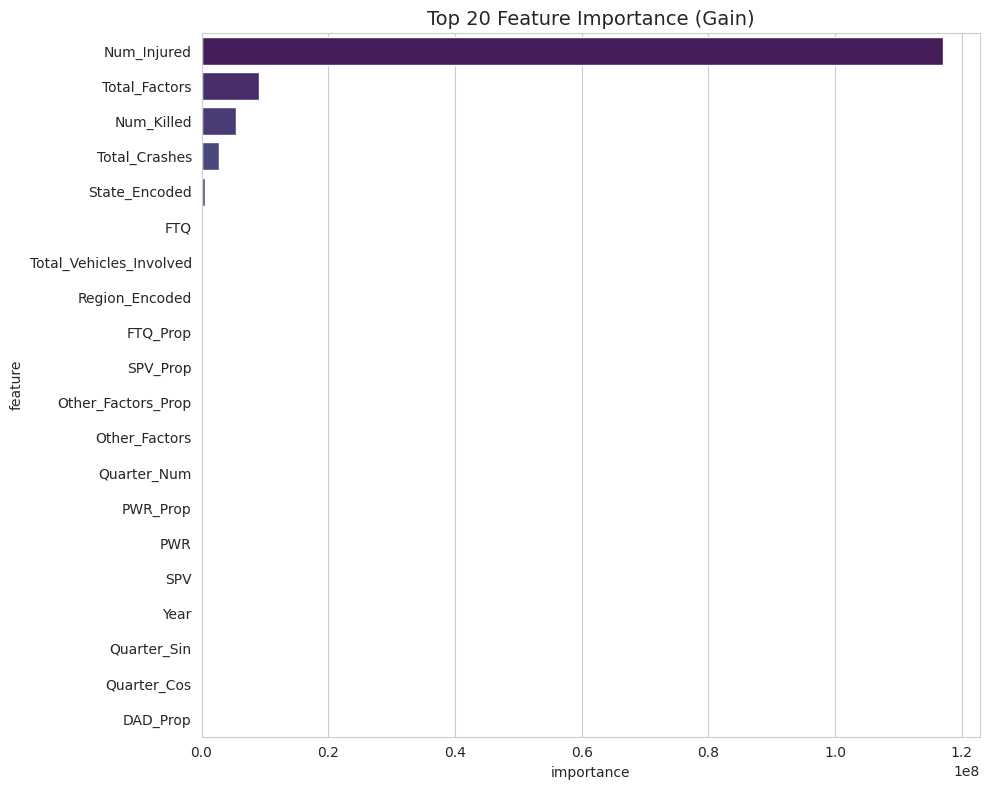

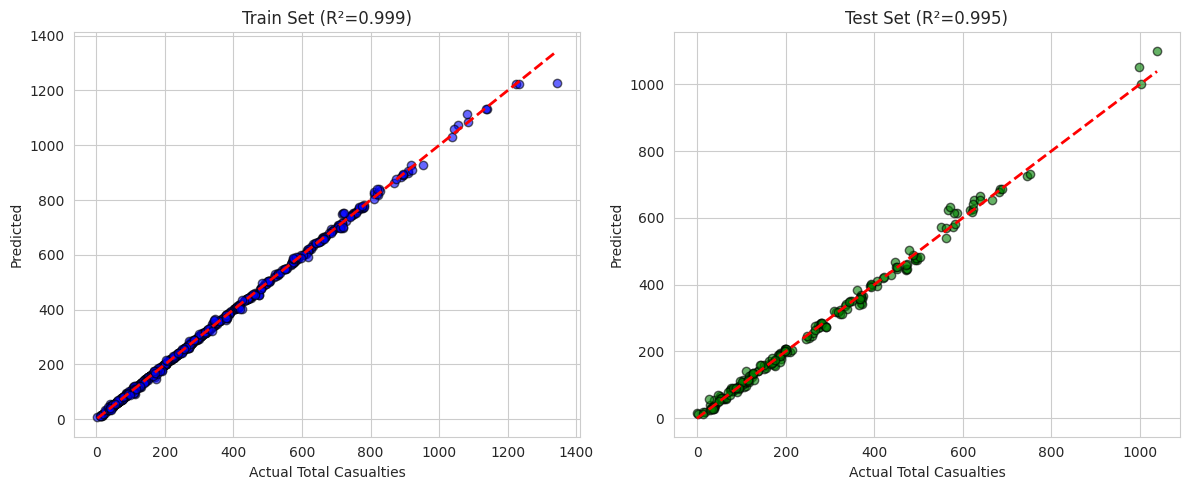

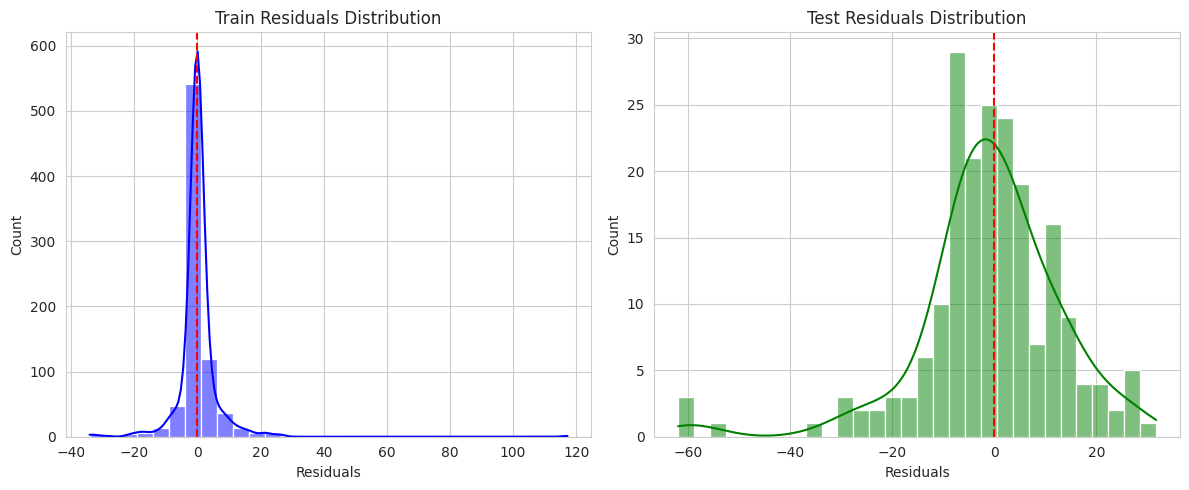

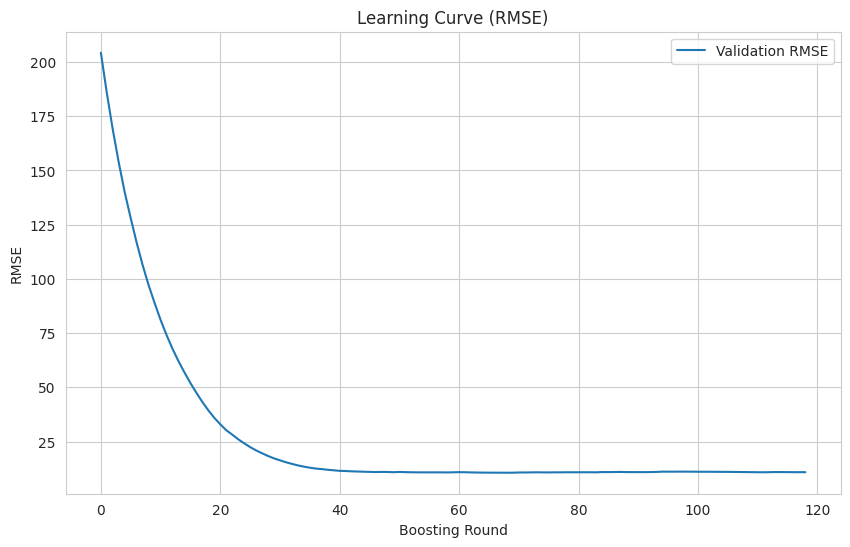

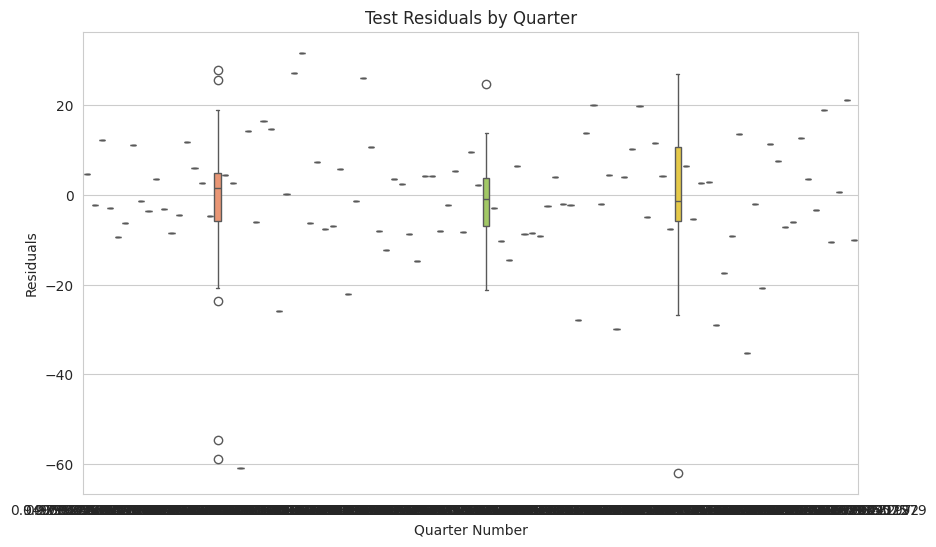


All plots saved as PNG files.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')

print("Dataset shape:", df.shape)

target = 'Total_Casualties'

drop_cols = [
    'Quarter', 'State', 'Quarter_Date',
    'Casualty_Rate', 'Fatality_Rate', 'Vehicles_per_Crash',
    'Severe_Crash', 'High_Casualty',
    'State_Adamawa', 'State_Akwa Ibom', 'State_Anambra', 'State_Bauchi', 'State_Bayelsa',
    'State_Benue', 'State_Borno', 'State_Cross River', 'State_Delta', 'State_Ebonyi',
    'State_Edo', 'State_Ekiti', 'State_Enugu', 'State_FCT', 'State_Gombe', 'State_Imo',
    'State_Jigawa', 'State_Kaduna', 'State_Kano', 'State_Katsina', 'State_Kebbi',
    'State_Kogi', 'State_Kwara', 'State_Lagos', 'State_Nasarawa', 'State_Niger',
    'State_Ogun', 'State_Ondo', 'State_Osun', 'State_Oyo', 'State_Plateau', 'State_Rivers',
    'State_Sokoto', 'State_Taraba', 'State_Yobe', 'State_Zamfara',
    'Region_North East', 'Region_North West', 'Region_South East', 'Region_South South', 'Region_South West',
    'Region'
]

feature_cols = [col for col in df.columns if col not in drop_cols and col != target and pd.api.types.is_numeric_dtype(df[col])]

print(f"\nNumber of numeric features: {len(feature_cols)}")
print("Features:\n", feature_cols)

X = df[feature_cols].copy()
y = df[target].copy()

if X.isnull().any().any():
    X = X.fillna(X.median())
if y.isnull().any():
    mask = y.notnull()
    X = X[mask]
    y = y[mask]

if 'Quarter_Date' in df.columns:
    df['Quarter_Date'] = pd.to_datetime(df['Quarter_Date'])
    sort_idx = df['Quarter_Date'].sort_values().index
else:
    sort_idx = df.sort_values(['Year', 'Quarter_Num']).index

X = X.loc[sort_idx]
y = y.loc[sort_idx]

split_ratio = 0.8
n_train = int(len(X) * split_ratio)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
if 'Quarter_Date' in df.columns:
    print(f"Train period: {df['Quarter_Date'].iloc[0]} to {df['Quarter_Date'].iloc[n_train-1]}")
    print(f"Test period: {df['Quarter_Date'].iloc[n_train]} to {df['Quarter_Date'].iloc[-1]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 10, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'verbosity': -1,
        'n_jobs': -1
    }
    X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, shuffle=False)
    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    model = lgb.train(params, train_data, valid_sets=[val_data], num_boost_round=1000,
                      callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse

print("\nStarting hyperparameter optimization with Optuna...")
study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_params['objective'] = 'regression'
best_params['metric'] = 'rmse'
best_params['verbosity'] = -1
best_params['n_jobs'] = -1
print("\nBest hyperparameters:", best_params)

X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, shuffle=False)

train_dataset = lgb.Dataset(X_tr, label=y_tr)
val_dataset = lgb.Dataset(X_val, label=y_val, reference=train_dataset)

evals_result = {}
callbacks = [lgb.early_stopping(50), lgb.log_evaluation(50), lgb.record_evaluation(evals_result)]
final_model = lgb.train(best_params,
                        train_dataset,
                        valid_sets=[val_dataset],
                        valid_names=['valid'],
                        num_boost_round=1000,
                        callbacks=callbacks)

y_train_pred = final_model.predict(X_train_scaled)
y_test_pred = final_model.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "="*50)
print("Model Performance")
print("="*50)
print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f} | Gap (Train - Test): {train_rmse - test_rmse:.4f}")
print(f"Train MAE : {train_mae:.4f} | Test MAE : {test_mae:.4f} | Gap: {train_mae - test_mae:.4f}")
print(f"Train R²  : {train_r2:.4f} | Test R²  : {test_r2:.4f} | Gap: {train_r2 - test_r2:.4f}")
print("="*50)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

importance = final_model.feature_importance(importance_type='gain')
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feat_imp_df, palette='viridis')
plt.title('Top 20 Feature Importance (Gain)', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.6, edgecolors='k', c='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted')
plt.title(f'Train Set (R²={train_r2:.3f})')
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', c='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted')
plt.title(f'Test Set (R²={test_r2:.3f})')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals_train, bins=30, kde=True, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.title('Train Residuals Distribution')
plt.subplot(1, 2, 2)
sns.histplot(residuals_test, bins=30, kde=True, color='green')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.title('Test Residuals Distribution')
plt.tight_layout()
plt.savefig('residuals.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
if 'valid' in evals_result and 'rmse' in evals_result['valid']:
    plt.plot(evals_result['valid']['rmse'], label='Validation RMSE')
    if 'training' in evals_result and 'rmse' in evals_result['training']:
        plt.plot(evals_result['training']['rmse'], label='Training RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('Learning Curve (RMSE)')
plt.legend()
plt.grid(True)
plt.savefig('learning_curve.png', dpi=150)
plt.show()

if 'Quarter_Num' in X_test.columns:
    test_residuals_df = pd.DataFrame({
        'Quarter_Num': X_test['Quarter_Num'],
        'Residuals': residuals_test
    })
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Quarter_Num', y='Residuals', data=test_residuals_df, palette='Set2')
    plt.title('Test Residuals by Quarter')
    plt.xlabel('Quarter Number')
    plt.ylabel('Residuals')
    plt.savefig('residuals_by_quarter.png', dpi=150)
    plt.show()

print("\nAll plots saved as PNG files.")